In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.linalg import toeplitz

C:\Users\Tadej\AppData\Local\Temp\ipykernel_20764\2302581876.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


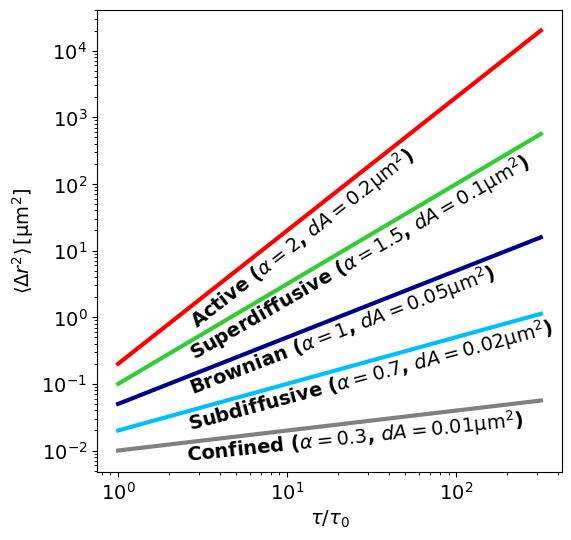

In [28]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'font.size': 14})

# Generate example data following different MSD scaling behaviors
t = np.logspace(0, 2.5, 1000)  # Log-spaced time values

# Different types of motion
MSD_directed = 0.2 * t**2
MSD_superdiffusive = 0.1 * t**1.5
MSD_brownian = 0.05 * t
MSD_subdiffusive = 0.02 * t**0.7
MSD_confined = 0.01 * t**0.3

# Create the plot
plt.figure(figsize=(6, 6))
plt.loglog(t, MSD_directed, label="Directed", color="red", linewidth=3)
plt.loglog(t, MSD_superdiffusive, label="Super-diffusive", color="limegreen", linewidth=3)
plt.loglog(t, MSD_brownian, label="Brownian", color="darkblue", linewidth=3)
plt.loglog(t, MSD_subdiffusive, label="Sub-diffusive", color="deepskyblue", linewidth=3)
plt.loglog(t, MSD_confined, label="Confined", color="gray", linewidth=3)

# Labels and styling
plt.xlabel(r"$\tau / \tau_0$", fontsize=14)
plt.ylabel(r"$\langle \Delta r^2 \rangle \, [\mathrm{\mu m}^2]$", fontsize=14)

# Annotate the curves with corresponding labels
plt.text(2.5, 0.7, r"Active ($\alpha = 2$, $dA = 0.2 \mathrm{\mu m}^2$)", fontsize=14, rotation=38, fontweight="bold")
plt.text(2.5, 0.23, r"Superdiffusive ($\alpha = 1.5$, $dA = 0.1 \mathrm{\mu m}^2$)", fontsize=14, rotation=30, fontweight="bold")
plt.text(2.5, 0.07, r"Brownian ($\alpha = 1$, $dA = 0.05 \mathrm{\mu m}^2$)", fontsize=14, rotation=21, fontweight="bold")
plt.text(2.5, 0.02, r"Subdiffusive ($\alpha = 0.7$, $dA = 0.02 \mathrm{\mu m}^2$)", fontsize=14, rotation=15, fontweight="bold")
plt.text(2.5, 0.0068, r"Confined ($\alpha = 0.3$, $dA = 0.01 \mathrm{\mu m}^2$)", fontsize=14, rotation=6, fontweight="bold")

# Show the plot
plt.show()


- Prikaz signalov iz datotek val2, val3 in co2

In [83]:
val2 = pd.read_csv("data/val2.dat")
val3 = pd.read_csv("data/val3.dat")
co2 = pd.read_csv("data/co2.dat", skiprows=16, delimiter=' ')

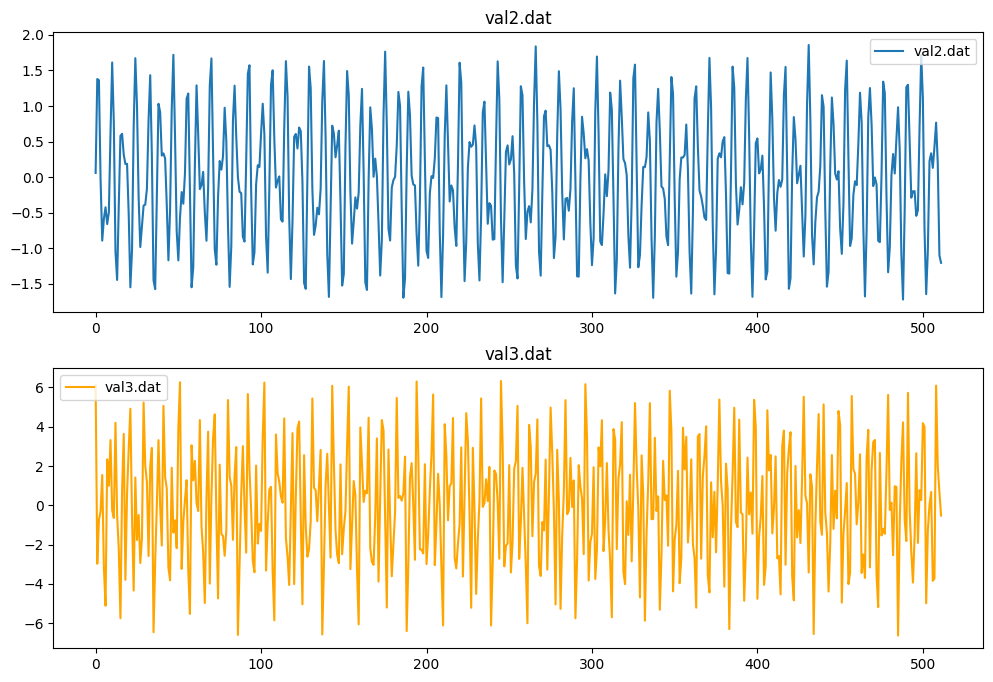

In [84]:
fig = plt.figure(figsize=(12, 8))

ax = fig.add_subplot(2, 1, 1)
ax.set_title('val2.dat')
ax.plot(val2.index, val2['value'].values, label='val2.dat')
ax.legend()

ax = fig.add_subplot(2, 1, 2)
ax.set_title('val3.dat')
ax.plot(val3.index, val3['value'].values, color='orange', label='val3.dat')
ax.legend()

In [113]:
def DFT(s, window='No window', sigma=100.): # Fourierova transformacija

    s = np.asarray(s, dtype=float)
    N = s.shape[0]

    if window == 'No window':
        w = np.ones(N, dtype=float)

    elif window == 'Bartlett':
        w = 1. - np.abs(np.arange(N, dtype=float) - float(N)/2.) / (float(N)/2.)

    elif window == 'Hann':
        w = 1./2. * (1. - np.cos(2.*np.pi*np.arange(N, dtype=float)/float(N)))

    elif window == 'Welch':
        w = 1. - ((np.arange(N, dtype=float) - float(N)/2.) / (float(N)/2.))**2.

    elif window == 'Gauss':
        w = np.exp(-((np.arange(N, dtype=float) - float(N)/2.)/sigma)**2.)

    S = np.zeros_like(s, dtype=complex)

    for i in range(0, N):
        a = 0.

        for k in range(N):
            a += w[k]*s[k]*np.exp(-1j * 2 * np.pi * k * i / N)

        S[i] = a

    # Power spectrum
    W = np.sum(w**2)
    P = np.zeros(round(N/2))
    P[0] = 1./W * np.abs(S[0])**2
    # P[-1] = 1./W * np.abs(S[round(N/2)])**2
    
    for i in range(1, len(P)):
        P[i] = 1./(2.*W) * (np.abs(S[i])**2 + np.abs(S[N-i])**2)

    return S, P


def autocorrelation(s):

    N = len(s)
    R = []

    for k in range(N):
        numerator = sum(s[n] * s[n - k] for n in range(k, N))
        R_k = numerator / (N - k)
        R.append(R_k)

    return np.array(R)


def solve_toeplitz_system(R, p):

    # Create the Toeplitz matrix M
    c = R[:p]
    r = R[:p]
    M = toeplitz(c, r)
    # Create the right-hand side vector b
    b = R[1:p + 1]
    # Solve the linear system
    a = np.linalg.solve(M, -b)

    return a


def predict(s, p, num=256):

    s_copy = s.copy()
    R = autocorrelation(s_copy)
    a = solve_toeplitz_system(R, p)

    for _ in range(num):
        sn = - np.sum(a*s_copy[-p:][::-1])
        s_copy = np.append(s_copy, sn)
    
    return pd.DataFrame({'value':s_copy})


def MESE(omega, s, p):

    R = autocorrelation(s)
    a = solve_toeplitz_system(R, p)
    G2 = R[0] + np.sum(a*R[1:p+1])
    P = G2 / np.abs((1 + np.sum(a * np.exp(-1j * omega * np.arange(1, p+1, dtype=complex)))))**2

    return P


def find_poles(s, p):
    
    R = autocorrelation(s)
    a = solve_toeplitz_system(R, p)
    # Construct the polynomial coefficients
    coeffs = [1] + list(a)  # Coefficients of z^0, z^1, ..., z^p
    # Find the zeros of the polynomial (poles of the passing function)
    poles = np.roots(coeffs)

    return poles

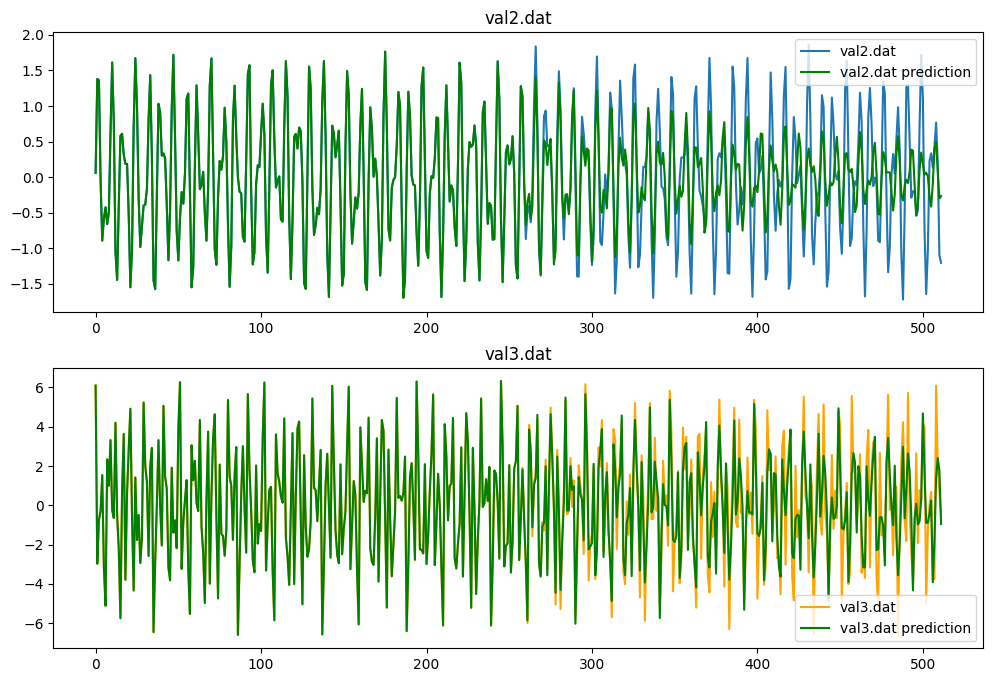

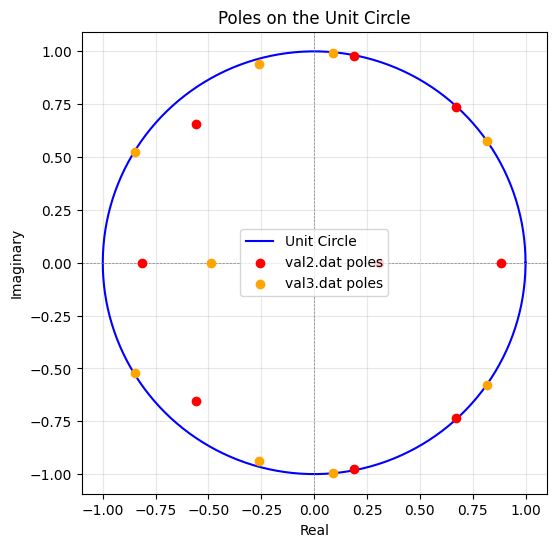

In [101]:
val2_test = val2[:256]
val3_test = val3[:256]
p = 9
val2_predict = predict(val2_test['value'].values, p)
val2_poles = find_poles(val2_test['value'].values, p)
val3_predict = predict(val3_test['value'].values, p)
val3_poles = find_poles(val3_test['value'].values, p)

fig = plt.figure(figsize=(12, 8))

ax = fig.add_subplot(2, 1, 1)
ax.set_title('val2.dat')
ax.plot(val2.index, val2['value'].values, label='val2.dat')
ax.plot(val3.index, val2_predict['value'].values, color='green', label='val2.dat prediction')
ax.legend()

ax = fig.add_subplot(2, 1, 2)
ax.set_title('val3.dat')
ax.plot(val3.index, val3['value'].values, color='orange', label='val3.dat')
ax.plot(val3.index, val3_predict['value'].values, color='green', label='val3.dat prediction')
ax.legend()

# Create the unit circle
theta = np.linspace(0, 2 * np.pi, 500)
unit_circle = np.exp(1j * theta)

# Plot the unit circle
plt.figure(figsize=(6, 6))
plt.plot(unit_circle.real, unit_circle.imag, 'b-', label="Unit Circle")

# Plot the val2_poles
plt.scatter(val2_poles.real, val2_poles.imag, color='red', label="val2.dat poles", zorder=5)
plt.scatter(val3_poles.real, val3_poles.imag, color='orange', label="val3.dat poles", zorder=5)

# Formatting the plot
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='datalim')
plt.title("Poles on the Unit Circle")
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [117]:
print(type(val2_test['value'].values))

<class 'numpy.ndarray'>


In [ ]:
N = len(val3['value'].values)
dt = 1.

nuc = 1. / (2. * dt)
nus = np.linspace(0., nuc, round(N/2))
dnu = nus[1]-nus[0]

S2, P2 = DFT(val2['value'].values)
S2_Bartlett, P2_Bartlett = DFT(val2['value'].values, window='Bartlett')
S2_Hann, P2_Hann = DFT(val2['value'].values, window='Hann')
S2_Welch, P2_Welch = DFT(val2['value'].values, window='Welch')
S2_Gauss, P2_Gauss = DFT(val2['value'].values, window='Gauss')
P2_MESE = MESE(1.+0j, val2_test['value'].values, 8)

S3, P3 = DFT(val3['value'].values)
S2_Bartlett, P3_Bartlett = DFT(val3['value'].values, window='Bartlett')
S3_Hann, P3_Hann = DFT(val3['value'].values, window='Hann')
S3_Welch, P3_Welch = DFT(val3['value'].values, window='Welch')
S3_Gauss, P3_Gauss = DFT(val3['value'].values, window='Gauss')

TypeError: cannot unpack non-iterable numpy.float64 object

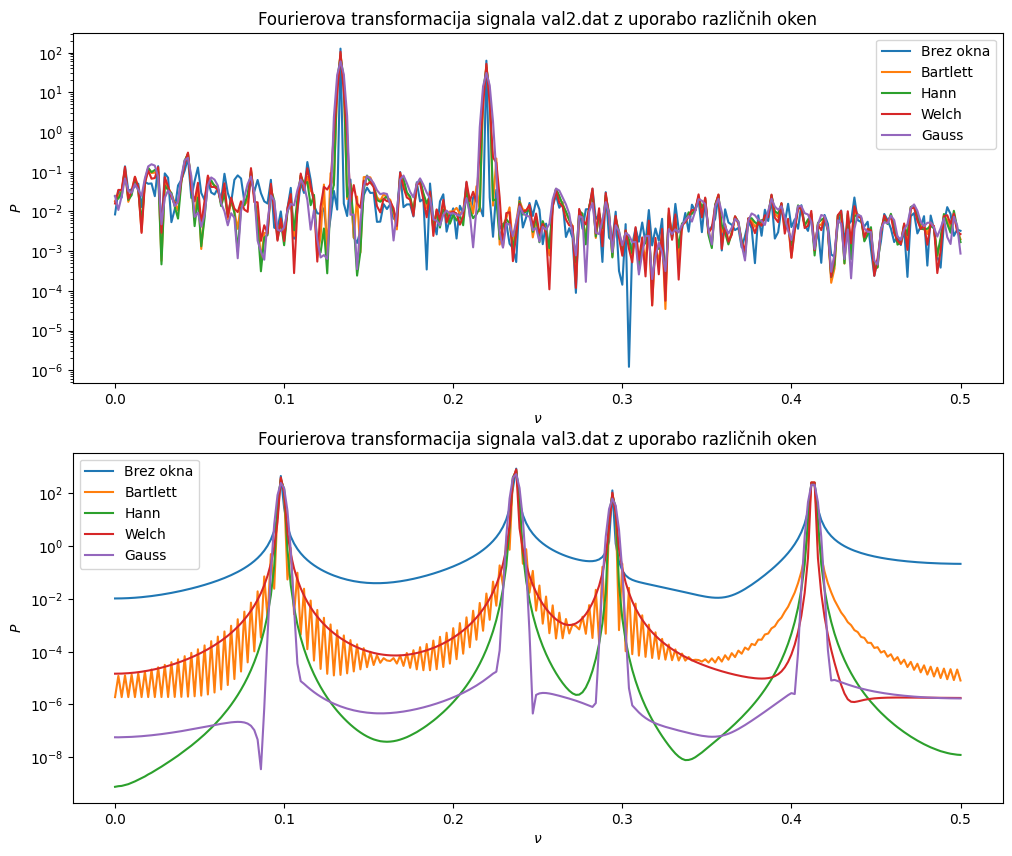

In [88]:
fig = plt.figure(figsize=(12, 10))

ax = fig.add_subplot(2, 1, 1)
ax.set_title('Fourierova transformacija signala val2.dat z uporabo različnih oken')
ax.set_xlabel(r'$\nu$')
ax.set_ylabel(r'$P$')
ax.set_yscale('log')
ax.plot(nus, P2, label='Brez okna')
ax.plot(nus, P2_Bartlett, label='Bartlett')
ax.plot(nus, P2_Hann, label='Hann')
ax.plot(nus, P2_Welch, label='Welch')
ax.plot(nus, P2_Gauss, label='Gauss')
#ax.set_ylim((0.0001, 100))
ax.legend()

# ax_inset = fig.add_axes([0.17, 0.56, 0.15, 0.10])
# ax_inset.set_yscale('log')
# ax_inset.plot(nus[30:39], P2[30:39], label='Brez okna')
# ax_inset.plot(nus[30:39], P2_Bartlett[30:39], label='Bartlett')
# ax_inset.plot(nus[30:39], P2_Hann[30:39], label='Hann')
# ax_inset.plot(nus[30:39], P2_Welch[30:39], label='Welch')
# ax_inset.plot(nus[30:39], P2_Gauss[30:39], label='Gauss')

# ax_inset = fig.add_axes([0.55, 0.75, 0.17, 0.11])
# ax_inset.set_yscale('log')
# ax_inset.plot(nus[48:65], P2[48:65], label='Brez okna')
# ax_inset.plot(nus[48:65], P2_Bartlett[48:65], label='Bartlett')
# ax_inset.plot(nus[48:65], P2_Hann[48:65], label='Hann')
# ax_inset.plot(nus[48:65], P2_Welch[48:65], label='Welch')
# ax_inset.plot(nus[48:65], P2_Gauss[48:65], label='Gauss')

ax = fig.add_subplot(2, 1, 2)
ax.set_title('Fourierova transformacija signala val3.dat z uporabo različnih oken')
ax.set_xlabel(r'$\nu$')
ax.set_ylabel(r'$P$')
ax.set_yscale('log')
ax.plot(nus, P3, label='Brez okna')
ax.plot(nus, P3_Bartlett, label='Bartlett')
ax.plot(nus, P3_Hann, label='Hann')
ax.plot(nus, P3_Welch, label='Welch')
ax.plot(nus, P3_Gauss, label='Gauss')
ax.legend()

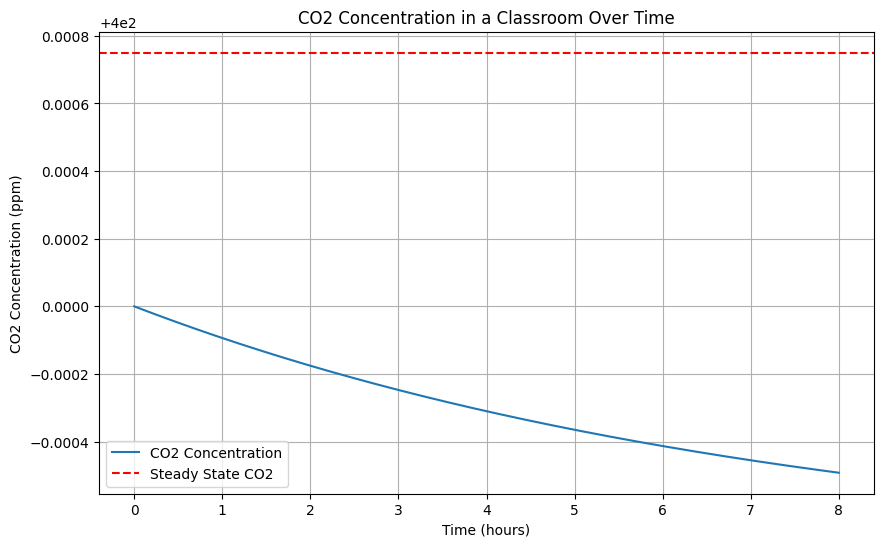

In [118]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
V = 50 * 10 * 3  # Classroom volume (length × width × height in m³)
N = 30  # Number of people
Re = 5 / 1000  # CO2 exhalation rate per person (m³/h)
Ca = 400  # Ambient CO2 concentration (ppm)
Q = 200  # Ventilation rate (m³/h)
C0 = 400  # Initial CO2 concentration (ppm)
time = np.linspace(0, 8, 1000)  # Time in hours (e.g., an 8-hour school day)

# Steady-state CO2 concentration
steady_state_increase = (N * Re) / Q
C_steady = Ca + steady_state_increase

# Analytical solution
C_t = Ca + (C0 - Ca + steady_state_increase) * np.exp(-Q / V * time) - steady_state_increase

# Plot
plt.figure(figsize=(10, 6))
plt.plot(time, C_t, label="CO2 Concentration")
plt.axhline(C_steady, color='r', linestyle='--', label="Steady State CO2")
plt.xlabel("Time (hours)")
plt.ylabel("CO2 Concentration (ppm)")
plt.title("CO2 Concentration in a Classroom Over Time")
plt.legend()
plt.grid()
plt.show()


In [5]:
delr = 10
D = 0.01

print(delr**2 / D)
print(10000/3600)

10000.0
2.7777777777777777


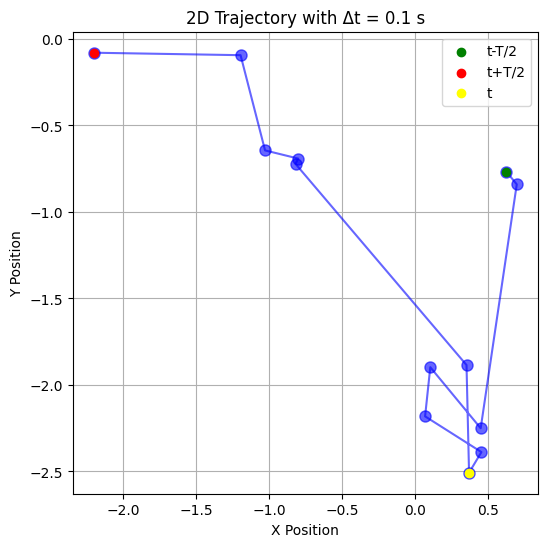

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def generate_2D_trajectory(num_steps=100, delta_t=1, step_size=1):
    """
    Generate a 2D trajectory using a simple random walk model.
    
    Parameters:
    - num_steps: Number of time steps in the trajectory.
    - delta_t: Time step duration.
    - step_size: Average step length per time step.
    
    Returns:
    - time: Array of time values.
    - x, y: Arrays of x and y coordinates.
    """
    time = np.arange(0, num_steps * delta_t, delta_t)  # Time points
    angles = np.random.uniform(0, 2 * np.pi, num_steps)  # Random angles
    dx = step_size * np.cos(angles)  # X displacements
    dy = step_size * np.sin(angles)  # Y displacements
    
    x = np.cumsum(dx)  # Cumulative x positions
    y = np.cumsum(dy)  # Cumulative y positions

    return time, x, y

# Parameters
num_steps = 13   # Number of steps
delta_t = 0.1     # Time step duration
step_size = np.random.exponential(0.5, 13)     # Step size per time step

# Generate trajectory
time, x, y = generate_2D_trajectory(num_steps, delta_t, step_size)

# Plot trajectory
plt.figure(figsize=(6, 6))
plt.plot(x, y, marker='o', markersize=8, linestyle='-', color='b', alpha=0.6)
plt.scatter(x[0], y[0], color='green', label="t-T/2", zorder=3)
plt.scatter(x[-1], y[-1], color='red', label="t+T/2", zorder=3)
plt.scatter(x[6], y[6], color='yellow', label="t", zorder=3)
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title(f"2D Trajectory with Δt = {delta_t} s")
plt.legend()
plt.grid(True)
plt.show()
